#BruvacAI
Designed a model that outputs **Flavor Text** for *Magic: The Gathering* cards using [Scryfall's Default Cards dataset](https://scryfall.com/docs/api/bulk-data).\
Architecture used includes:
*   **Unsloth** (open-source) as a Machine Learning framework
*   **LoRA** as a method of Parameter Efficient Fine-Tuning (using Unsloth's packages)
*   **llama-3.2-1b-instruct** - pretrained model to tune to the task




In [ ]:
!pip install --no-deps unsloth unsloth_zoo trl peft accelerate bitsandbytes


#1 - Dataloading (and other setup)

##1A - Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import json
path = "/content/drive/MyDrive/default_cards.json"

with open(path, "r", encoding="utf-8") as f:
    cards = json.load(f)

##1B - Preprocessing
Preprocessing will be important in order to cleanse data from 30 years of original cards and reprints. Deduplication will be handled based on name-flavor pairings, and cards with no flavor text will be removed due to lack of value during training. Additionally, it will be highly necessary to filter out basic lands and tokens.

In [ ]:
##helper method to filter basic lands, tokens, etc
def filter_extraneous_cards(cards_to_filter: list[str]):
  valid_cards = []
  for card in cards_to_filter:
    type_line = card["type_line"]
    if type_line.startswith("Basic Land"):
      continue
    if type_line.startswith("Token"):
      continue
    valid_cards.append(card)
  return valid_cards

#important to note that multiple prints of the same cards are valid
def deduplicate(cards_to_dedupe: list[str]):
  seen = set()
  deduped = []
  for c in cards:
      name = c.get("name")
      flavor = c.get("flavor_text")
      if not flavor:
          continue
      key_tuple = (name, flavor.strip())
      if key_tuple not in seen:
          seen.add(key_tuple)
          deduped.append(c)

  return(deduped)

cards_with_flavor = [c for c in cards if c.get("flavor_text")]
valid_cards = filter_extraneous_cards(cards_with_flavor)
deduplicated_cards = deduplicate(valid_cards)


#2 - Loading the Model
For this task, we use pre-trained **llama-3.2-1b-instruct**, an instruction-tuned model that can be fine-tuned easily. The Llama 3.2 collection includes multiple models including 1B and 3B parameter versions.
My decision to use the 1-billion parameter version can be attributed to multiple performance and compute reasons:
- The task scope is narrow enough to use a smaller model due to the short-form, stylized manner of MTG Flavor Text. A smaller model also reduces the chance of overfitting.
- Additionally, a smaller model allows for greater memory headroom for LoRA as well as reduced training time.  

In [ ]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-1B-Instruct-bnb-4bit",
    max_seq_length = 512,
    dtype = None,
    load_in_4bit = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 32,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                       "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 32,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = True,
    random_state = 42,
)
#verify trainable param reduction
model.print_trainable_parameters()

To generate the prompt, we assign the model's role, content, and the "answer" (the ground truth flavor text).

In [ ]:
def build_message_for_card(card, drop_rules=False):
    name = card.get("name", "")
    mana_cost = card.get("mana_cost", "")
    type_line = card.get("type_line", "")
    oracle_text = card.get("oracle_text", "") if not drop_rules else ""

    # truncate rules text at 200
    if len(oracle_text) > 200:
        oracle_text = oracle_text[:200].rsplit(" ", 1)[0] + "..."

    user_content = (
        f"Rules text: {oracle_text}\n"
        f"Mana cost: {mana_cost}\n"
        f"Card name: {name}\n"
        f"Type: {type_line}\n\n"
        f"Write evocative Magic: The Gathering flavor text for {name}, a {type_line}."
    )

    return [
        {"role": "system", "content": "You are a creative writer generating short, evocative flavor text for Magic: The Gathering cards."},
        {"role": "user", "content": user_content},
        #answer
        {"role": "assistant", "content": card["flavor_text"].strip()},
    ]

#3 - Training loop

Prompt generation is extremely important for an instruction-tuned model. The drop_rules parameter allows for dropout during training in order to have a certain percentage of cards fully rely on non-rules data such as name and typeline in order to reduce dependency on the rules text.

In [ ]:
import random

def get_card_fields(card, drop_rules: bool):
    if "card_faces" in card and not card.get("flavor_text"):
        # use the front face for input fields, but flavor text might be per-face
        face = card["card_faces"][0]
        return {
            "name": card.get("name", face.get("name", "")),
            "mana_cost": face.get("mana_cost", card.get("mana_cost", "")),
            "type_line": face.get("type_line", card.get("type_line", "")),
            "oracle_text": face.get("oracle_text", ""),
            "flavor_text": face.get("flavor_text", card.get("flavor_text", "")),
        }
    ##dropout will be used to have the model skip rules text at times to not get bogged down in it
    if drop_rules:
        return{
            "name": card.get("name", ""),
            "mana_cost": card.get("mana_cost", ""),
            "type_line": card.get("type_line", ""),
            "oracle_text": "",
            "flavor_text": card.get("flavor_text", ""),
        }
    return {
        "name": card.get("name", ""),
        "mana_cost": card.get("mana_cost", ""),
        "type_line": card.get("type_line", ""),
        "oracle_text": card.get("oracle_text", ""),
        "flavor_text": card.get("flavor_text", ""),
    }


In [ ]:
from sklearn.model_selection import train_test_split

def split_cards(custom_tvt_split={}):
"""
Splits cards based on names rather than IDs so that duplications end up in the same set
"""
  if custom_tvt_split == {}:
    custom_tvt_split = {"train": 85, "val": 10, "test": 5}

  train_size = custom_tvt_split["train"] / 100
  val_size = custom_tvt_split["val"] / 100
  test_data_size = custom_tvt_split["test"] / 100
  temp_size = val_size+test_data_size

  test_size_proportion = test_size=test_data_size / temp_size

  #Duplications must be in the same set!
  unique_names = list(set(c["name"] for c in deduplicated_cards))
  train_names, temp_names = train_test_split(unique_names, test_size=temp_size, random_state=42)
  val_names, test_names = train_test_split(temp_names, test_size= test_size_proportion, random_state=42)

  train_names_set = set(train_names)
  val_names_set = set(val_names)
  test_names_set = set(test_names)

  train_set = [c for c in deduplicated_cards if c["name"] in train_names_set]
  val_set   = [c for c in deduplicated_cards if c["name"] in val_names_set]
  test_set  = [c for c in deduplicated_cards if c["name"] in test_names_set]

  return train_set, val_set, test_set

train_set, val_set, test_set = split_cards()

In [ ]:
import random

def format_for_training(card):
    dropout_rate = 0.20
    drop_rules = random.random() < dropout_rate
    messages = build_message_for_card(card, drop_rules=drop_rules)

    return {"text": tokenizer.apply_chat_template(messages, tokenize=False)}

from datasets import Dataset
train_ds = Dataset.from_list([format_for_training(c) for c in train_set])
val_ds   = Dataset.from_list([format_for_training(c) for c in val_set])

In [ ]:
from trl import SFTTrainer, SFTConfig
import torch
from unsloth.chat_templates import train_on_responses_only

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_ds,
    eval_dataset = val_ds,
    args = SFTConfig(
        dataset_text_field = "text",
        max_seq_length = 512,
        packing = False,
        padding_free = False,   # required when packing=False + max_seq_length is set
        per_device_train_batch_size = 8,
        gradient_accumulation_steps = 2,   # keeps effective batch size = 16
        warmup_steps = 10,
        num_train_epochs = 3,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 20,
        eval_strategy = "epoch",
        save_strategy = "epoch",
        optim = "adamw_8bit",
        output_dir = "outputs",
        report_to = "none",
    ),
)

trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|start_header_id|>user<|end_header_id|>\n\n",
    response_part = "<|start_header_id|>assistant<|end_header_id|>\n\n",
)

Training the model here!

In [ ]:
trainer_stats = trainer.train()

#4 - Saving the Model!

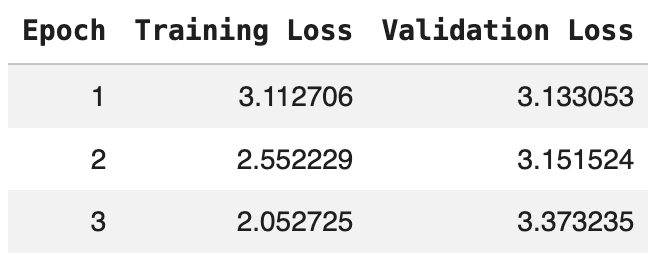

By the above table, we use the model's weights after Epoch 1 as it has the lowest validation loss. In future epochs, it appears that the model overfit on training data due to greatly improved training loss despite weaker validation performance.

In [ ]:
import os
import shutil
from unsloth import FastLanguageModel

#confirm checkpoint folders
print("Available checkpoints:", sorted(os.listdir("outputs")))

#load the epoch-1 checkpoint
epoch1_checkpoint = "outputs/checkpoint-1444"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = epoch1_checkpoint,
    max_seq_length = 512,
    dtype = None,
    load_in_4bit = True,
)

#save as the final chosen model
model.save_pretrained("mtg_flavor_lora_best")
tokenizer.save_pretrained("mtg_flavor_lora_best")

shutil.copytree("mtg_flavor_lora_best", "/content/drive/MyDrive/mtg_flavor_lora_best", dirs_exist_ok=True)

model.print_trainable_parameters()

#5 - Testing (with validation data)

In [ ]:
FastLanguageModel.for_inference(model)

for test_card in val_set[20:40]:
    messages = build_message_for_card(test_card, drop_rules=False)[:2]  # system + user only, no assistant turn
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")

    outputs = model.generate(
        inputs,
        max_new_tokens=60,
        temperature=0.8,
        top_p=0.9,
        do_sample=True,
    )
    generated = tokenizer.decode(outputs[0][inputs.shape[-1]:], skip_special_tokens=True)


# BruvacAI — Sample Outputs (Epoch 1 checkpoint)

---

### Sinew Sliver

**Generated:**
With the rise of Phyrexia, many Eldrazi, including the Slivers, became agents of change, seeking to preserve their homeworlds.

**Actual:**
As the muscle cords of the creature twitched, Hanna saw an unsettling unanimity in the others' rippling flesh. She didn't know what it meant, but she urged Sisay to keep the ship at a safe distance.

---

### Invisible Stalker

**Generated:**
"Have you seen those? They're like ghosts. I can be right on them, but they don't seem to be moving."
—Kami, street artist

**Actual:**
"All that concerns me is the vampires' sense of smell and those freezing Nephalian nights."

---

### Gorion, Wise Mentor

**Generated:**
He gave the greatest of gifts: wisdom.

**Actual:**
"You are safest in Candlekeep, Abdel, but I cannot keep you from the world forever."

---

### Second Breakfast

**Generated:**
"If you're hungry, you should eat now. If you're not hungry, you should eat now."

**Actual:**
The Hobbits of the Shire were fond of six meals a day—when they could get them.

---

### Unholy Strength

**Generated:**
"Strength is not the sum of your muscles. It is the difference between your muscles and your mind."
—Rabindranath Tagore

**Actual:**
"I don't *feel* any different."

---

### Mwonvuli Beast Tracker

**Generated:**
The Mwonvuli be called the "big cats," but only by those who know how to find them.

**Actual:**
"The more dangerous, the better."

---

### Mise

**Generated:**
"The best part about being a thief is getting to take something that wasn't *that* important."
—Hanna

**Actual:**
mise 'mīz v [alter. of might as well] (1997) 1: to win when you don't deserve to 2: to top-deck the "tings" you need 3: to be rewarded by an opponent's bad luck 4: to coin a phrase that spreads through the tournament scene like wildfire 5: to fling a monkey 6: to split firewood using a sharp instrument 7: To burn

---

### Duelist's Heritage

**Generated:**
"You think you can take on my family? I think you can take on my sword."

**Actual:**
The best techniques outlive their creators.

---

### Phyresis

**Generated:**
"I have given a new form to a plague that has plagued me for years."
—Razia, the Turdokken

**Actual:**
"Perfection is at hand. You have been freed of weakness and made *compleat*."
—Sheoldred, Whispering One

---

### Nin, the Pain Artist

**Generated:**
"His touch is like ice."

**Actual:**
"Your body is a delicate instrument that tells me truths. These devices help me 'tune' that instrument."